## Set up

In [1]:
#importing packages
#packages for directory and file handling
import os
import glob
import json

#packages for time handling
import time as pytime
from sqlite3 import Date
import datetime

#packages for flow cytometry data handling
import FlowCal

#packages for data handling
import pprint
import re
from datetime import date
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype

#packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.ticker as ticker

In [2]:
#fontsize =7
def custom_theme_7pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 7
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 7
    plt.rcParams['legend.title_fontsize'] = 7
    plt.rcParams['axes.labelsize'] = 7
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['axes.grid'] = False

    #additionas to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42 


#fontsize = 6
def custom_theme_6pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 6
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 6
    plt.rcParams['legend.title_fontsize'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 6
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


#fontsize =5
def custom_theme_5pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 5
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['legend.title_fontsize'] = 5
    plt.rcParams['axes.labelsize'] = 5
    plt.rcParams['axes.titlesize'] = 5
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

In [3]:
#get all subdirs in fcs_files (corresponding to experiments)
os.getcwd()
files = glob.glob('fcs_files/*fcs')
sorted_files = sorted(files)
sorted_files[:5]

#import all files in the dictionary and save as new dictionary
imported_files = {}
for filename in sorted_files:
    fcs_data = FlowCal.io.FCSData(filename)
    imported_files[filename] = fcs_data

#check the shape of the imported files
keys_shapes = []
for key, value in imported_files.items():
    keys_shapes.append(f"{key}: {value.shape}")

#make the output more readable (uncomment to inspect)
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(keys_shapes)

[   'fcs_files/Controls_Fully unstained_004.fcs: (18128, 9)',
    'fcs_files/Controls_Unstained + D7_005.fcs: (37386, 9)',
    'fcs_files/Fully stained samples_H9_003.fcs: (36776, 9)',
    'fcs_files/Fully stained samples_KOLF_001.fcs: (42974, 9)',
    'fcs_files/Fully stained samples_RC17_002.fcs: (29992, 9)']


## Plot data

Plot as histogram

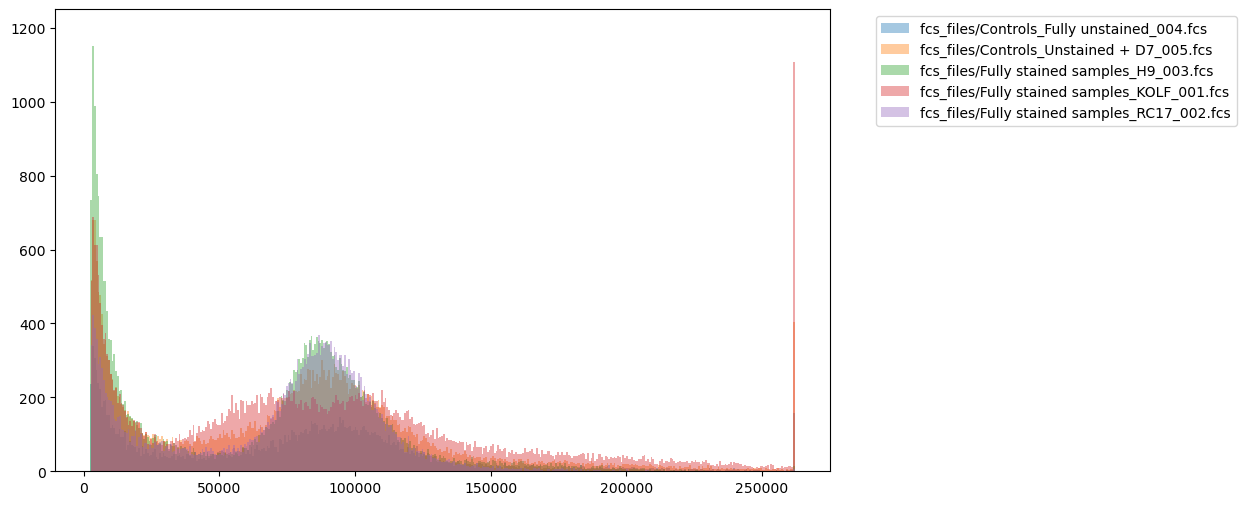

In [4]:
plt.figure(figsize=(10, 6)) # make the figure wider
for i, (filename, file) in enumerate(imported_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, 
                label=f'{folder_name}/{os.path.basename(filename)}')

plt.ylim(0, 1250)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Plot to define gating strategy

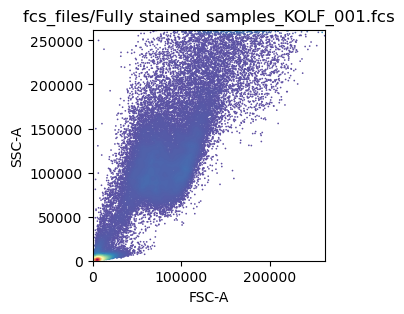

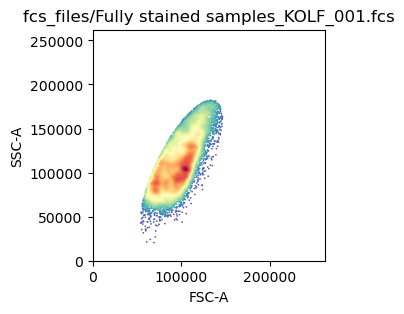

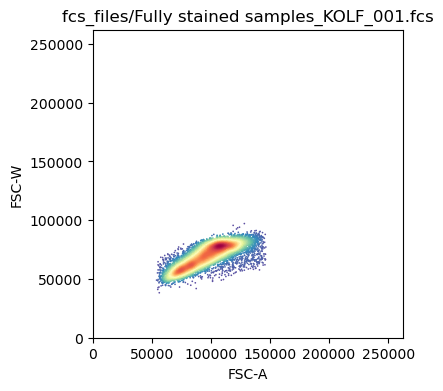

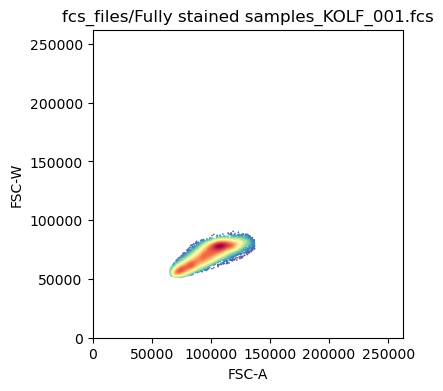

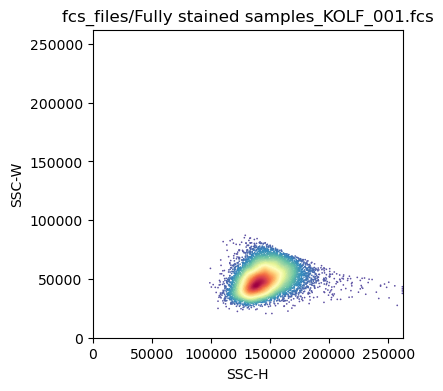

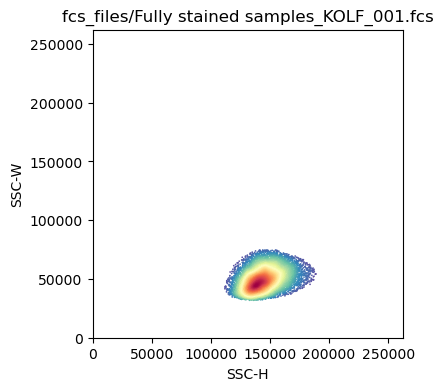

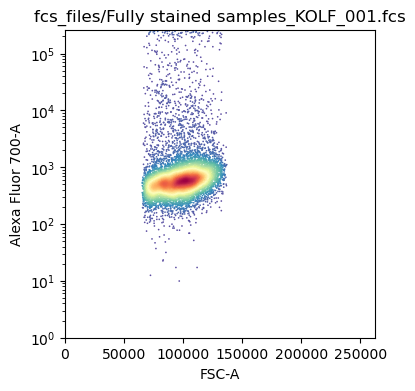

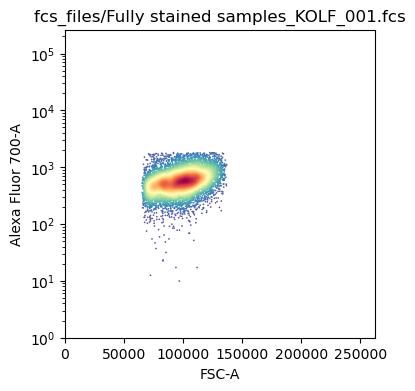

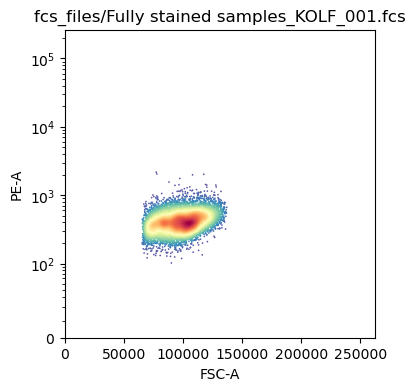

Number of events in gated sample: 9205


In [5]:
#plot with FlowCal.plot.density2d
count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    if 'KOLF' not in filename:
        continue
    count += 1
    if count > 5:
        break
    
    #plot the fsc-a vs ssc-a
    plt.figure(figsize=(3, 3)) # make the figure wider
    FlowCal.plot.density2d(file, channels=['FSC-A', 'SSC-A'], mode='scatter', yscale = 'linear', xscale='linear')
    plt.title(filename)
    plt.show()


    #gate the data
    s = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                            center=(1e5, 1e5), #center (xy coordinates)
                            a=30000, #width
                            b=90000, #height
                            theta=-25/180.*np.pi #rotation
                            )
    
    #plot the cell gate
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(s, channels=['FSC-A','SSC-A'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in fsc-a/fsc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #3.(density) fsc-a gate
    s = FlowCal.gate.density2d(s, channels=['FSC-A','FSC-W'], gate_fraction=0.90)


    #plot the singlets-fsc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in ssc-h/ssc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    #4. (density) singlets-ssc gate
    s = FlowCal.gate.density2d(s, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
    
    #plot the singlets-ssc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in draq7
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()

     #5. (threshhold) live gate
    s = FlowCal.gate.high_low(s, channels=['Alexa Fluor 700-A'], high=1800)

    #plot the data 
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    #6. gating in markers of interest    
    #6.1 pe
    #plot the data as density plot
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','PE-A'],  mode='scatter', xscale='linear', yscale='logicle')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    print(f"Number of events in gated sample: {s.shape[0]}")

## Create cut-off dictionary

In [6]:
# calculate relevant metric for the fmo's of the for each fluorophore and folder
fmo_percentiles = {'PE': []}
fmo_means = {'PE': []}
fmo_stds = {'PE': []}

for i, (filename, file) in enumerate(imported_files.items()):
    if 'Unstained + D7' in filename:
        
        #gate the cells
        g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1e5, 1e5), a=30000, b=90000, theta=-25/180.*np.pi)
        g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
        g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
        g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)

        #calculate the 99.8th percentile of the fmo's
        if 'PE-A' in g4.channels:
            fmo_percentiles['PE'].append(np.percentile(g4[:, 'PE-A'], 99.9))
            fmo_means['PE'].append(np.mean(g4[:, 'PE-A']))
            fmo_stds['PE'].append(np.std(g4[:, 'PE-A']))


# retrieve the relevant metrics for each fluorophore, separately for each folder and fluorophore
perc_cutoffs = {k: np.mean(v) for k, v in fmo_percentiles.items()}
mean_of_means = {k: np.mean(v) for k, v in fmo_means.items()}
mean_of_stds = {k: np.mean(v) for k, v in fmo_stds.items()}
std_cutoffs_3 = {k: mean + 3*std for k, mean, std in zip(mean_of_means.keys(), mean_of_means.values(), mean_of_stds.values())}
std_cutoffs_8 = {k: mean + 8*std for k, mean, std in zip(mean_of_means.keys(), mean_of_means.values(), mean_of_stds.values())}

#print the results
print(f"99.8th% cutoffs:\n {perc_cutoffs}")
print(f"Mean+3SD cutoffs:\n {std_cutoffs_3}")
print(f"Mean+8SD cutoffs:\n {std_cutoffs_8}")

99.8th% cutoffs:
 {'PE': 1051.9906606445334}
Mean+3SD cutoffs:
 {'PE': 749.5193328857422}
Mean+8SD cutoffs:
 {'PE': 1450.6207885742188}


# Plot

## Plot the data with the cut-off values

Processing... fcs_files/Controls_Fully unstained_004.fcs
Processing... fcs_files/Controls_Unstained + D7_005.fcs
Processing... fcs_files/Fully stained samples_H9_003.fcs


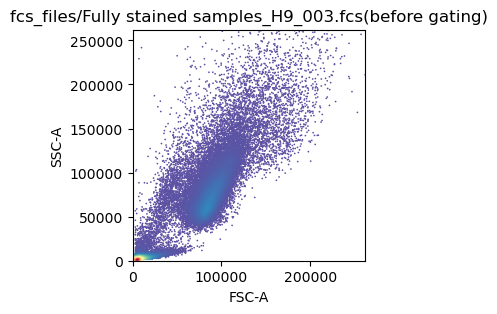

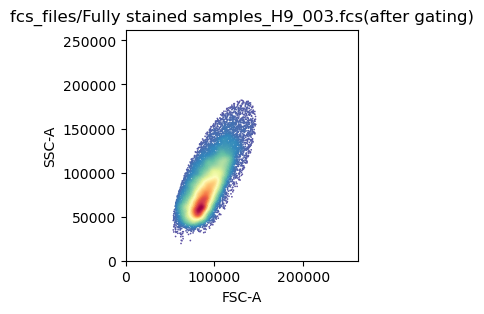

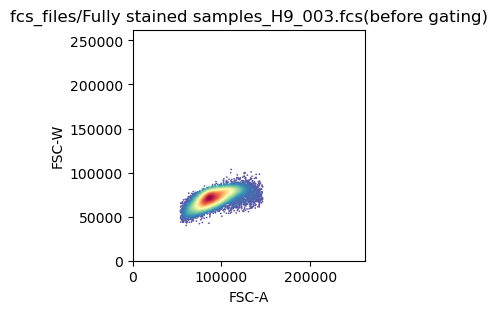

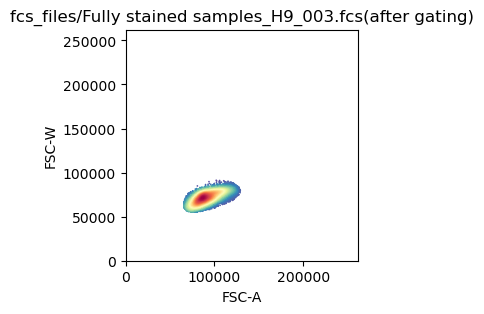

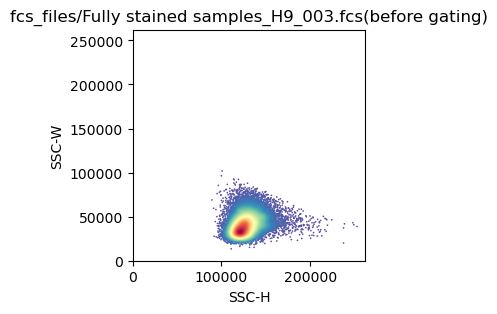

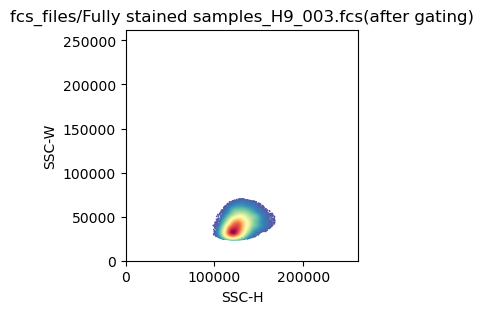

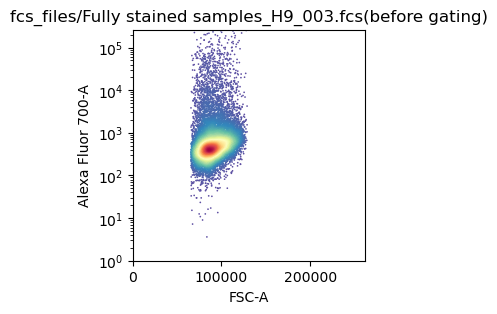

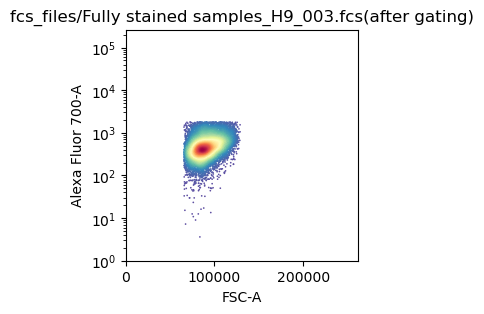

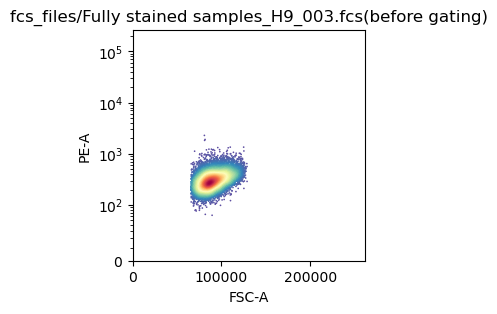

Cutoff key for PE-A: PE, Cutoff value: 1051.9906606445334


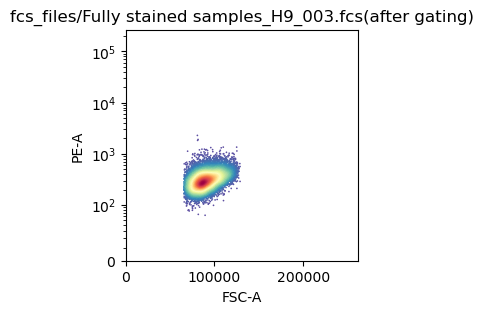

Applying gate on PE-A with cutoff 1051.9906606445334 (inverse=True)
Initial count: 14394, Final count after gating: 22, Percentage retained: 0.15%


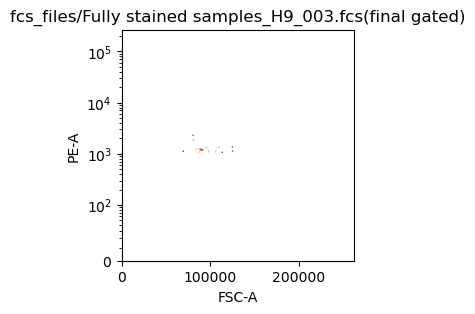

Processing... fcs_files/Fully stained samples_KOLF_001.fcs
Processing... fcs_files/Fully stained samples_RC17_002.fcs


In [ ]:
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(g, channels=channels, mode=mode, xscale=xscale, yscale=yscale)
    plt.title(title)
    plt.show()

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g

#channel to cutoff mapping
channel_to_cutoff_key = {'PE-A': 'PE'}

# plot and gate the data
#count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    print(f'Processing... {filename}')
    if 'H9' not in filename:
        continue
    #if 'IAP' not in filename:
        #continue
    #count += 1
    #if count >= 6:
        #break

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1e5, 1e5), a=30000, b=90000, theta=-25/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')
    #print(f"Number of live cells: {g4.shape[0]}")


    if 'Fully' in filename or 'Control' in filename:
        g4 = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(before gating)', yscale='logicle', gate=True)
        cutoff_key = channel_to_cutoff_key.get('PE-A')
        print(f"Cutoff key for PE-A: {cutoff_key}, Cutoff value: {perc_cutoffs.get(cutoff_key)}")
        g5_pe = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs[cutoff_key], inverse=True)
        #use g5_pe
        plot_and_gate(g5_pe, ['FSC-A', 'PE-A'], filename + '(final gated)', yscale='logicle')
    else:
        print(f"Skipping {filename} as it does not contain the relevant markers.")
        continue

## Plot gating

Processing... fcs_files/Controls_Fully unstained_004.fcs


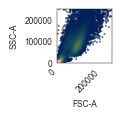

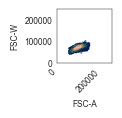

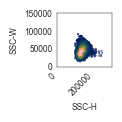

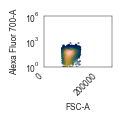

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_1716/3582838072.py:28: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(ylim)


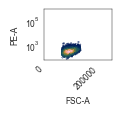

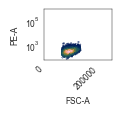

Applying gate on PE-A with cutoff 749.5193328857422 (inverse=True)
Initial count: 5991, Final count after gating: 96, Percentage retained: 1.6%
Processing... fcs_files/Controls_Unstained + D7_005.fcs


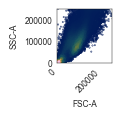

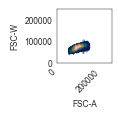

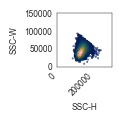

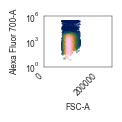

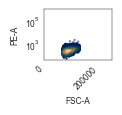

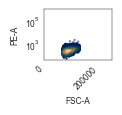

Applying gate on PE-A with cutoff 749.5193328857422 (inverse=True)
Initial count: 12498, Final count after gating: 167, Percentage retained: 1.34%
Processing... fcs_files/Fully stained samples_H9_003.fcs


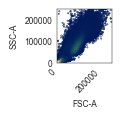

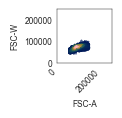

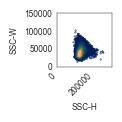

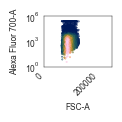

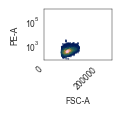

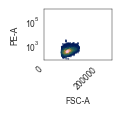

Applying gate on PE-A with cutoff 749.5193328857422 (inverse=True)
Initial count: 14394, Final count after gating: 175, Percentage retained: 1.22%
Processing... fcs_files/Fully stained samples_KOLF_001.fcs


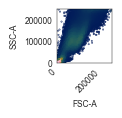

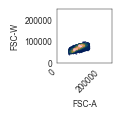

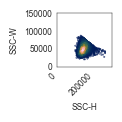

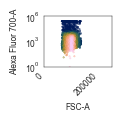

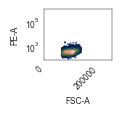

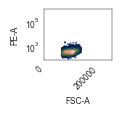

Applying gate on PE-A with cutoff 749.5193328857422 (inverse=True)
Initial count: 9205, Final count after gating: 349, Percentage retained: 3.79%
Processing... fcs_files/Fully stained samples_RC17_002.fcs


In [ ]:
custom_theme_6pt()

#adjust colormap for density coloring
def modify_colormap_alpha(cmap, alpha=1.0):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha  # Set the alpha channel
    return LinearSegmentedColormap.from_list(f"{cmap.name}_opaque", colors)

#load and modify colormap
with open("../../../color_palettes/batlow_colors.txt") as f:
    bilbao_colors = [line.strip() for line in f]
bilbao_cmap = LinearSegmentedColormap.from_list("bilbao", bilbao_colors)
opaque_bilbao_cmap = modify_colormap_alpha(bilbao_cmap, alpha=1.0)

#define function for density-colored plots
def density_scatter(x, y, xscale='linear', yscale='linear', 
                    xlim=None, ylim=None,
                    xlabel='', ylabel='', save_path=None):
    plt.figure(figsize=(1.2, 1.2))
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))
    plt.scatter(x, y, c=colors, s=0.1, label='Events')
    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save_path:
        #ensure directory exists
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=100)
    plt.show()

#plot_and_gate function
def plot_and_gate(g, channels, mode='scatter', xscale='linear', yscale='linear', xlim=None, ylim=None, gate=None, cutoff=None, inverse=False, save_path=None):
    x = g[:, g.channels.index(channels[0])].astype('<f8')
    y = g[:, g.channels.index(channels[1])].astype('<f8')
    density_scatter(x, y, xscale=xscale, yscale=yscale, xlim=xlim, ylim=ylim, xlabel=channels[0], ylabel=channels[1], save_path=save_path)

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g

#channel to cutoff mapping
channel_to_cutoff_key = {'PE-A': 'PE', 'Alexa Fluor 488-A': 'AF488', 'PE-Cy7-A': 'PE-Cy7'}

#process the data
count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    print(f'Processing... {filename}')
    count += 1
    if count >= 5:
        break

    plot_and_gate(file, ['FSC-A', 'SSC-A'], 
                  xlim=(0, 2.5e5), ylim=(0, 2.5e5),
                  save_path=f"facs_plots/{filename}_before_gating.pdf")

    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A', 'SSC-A'], center=(1e5, 1e5), a=30000, b=90000, theta=-25/180.*np.pi)
    plot_and_gate(g1, ['FSC-A', 'FSC-W'], 
                  xlim=(0, 2.5e5), ylim=(0, 2.5e5),
                  save_path=f"facs_plots/{filename}_fsc-a_fsc-w_gating.pdf")

    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['SSC-H', 'SSC-W'], 
                  xlim=(0, 3e5), ylim=(0, 1.5e5),
                  save_path=f"facs_plots/{filename}_ssc-h_ssc-w_gating.pdf")

    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.93)
    plot_and_gate(g3, ['FSC-A', 'Alexa Fluor 700-A'],  
                  xlim=(0, 2.5e5), ylim=(1, 1e6),
                  yscale='log',
                  save_path=f"facs_plots/{filename}_draq7_gating.pdf")

    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)
    plot_and_gate(g4, ['FSC-A', 'PE-A'], 
                  xlim=(0, 2.5e5), ylim=(0, 1e6), 
                  yscale='log', save_path=f"facs_plots/{filename}_pre_fluo_gating.pdf")

    if 'PE-A' in g4.channels:
        g5_pe = plot_and_gate(g4, ['FSC-A', 'PE-A'], 
                              yscale='log', 
                              xlim=(0, 2.5e5), ylim=(0, 1e6),
                              gate=True, cutoff=std_cutoffs_3['PE'], 
                              inverse=True, save_path=f"facs_plots/{filename}_pe_gating.pdf")

## Plot density

Plotting scatter plot for fcs_files/Controls_Fully unstained_004.fcs with gating for PE


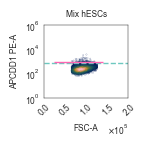

Plotting scatter plot for fcs_files/Controls_Unstained + D7_005.fcs with gating for PE


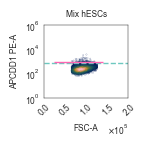

Plotting scatter plot for fcs_files/Fully stained samples_H9_003.fcs with gating for PE


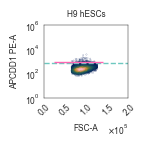

Plotting scatter plot for fcs_files/Fully stained samples_KOLF_001.fcs with gating for PE


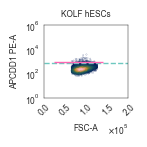

Plotting scatter plot for fcs_files/Fully stained samples_RC17_002.fcs with gating for PE


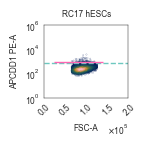

In [ ]:
#regions_of_interest = ['dFB', 'cVM']
#dates_of_interest = ['200628', '200702', 'LRTM1_other_2ndary', '210310', '210317']
strings_keep = ['Unstained', 
                #'AH068', 'AH069', 'AH071', 'AH072',
                'dFB', 'rVM', 'cVM']

custom_theme_6pt()

#adjust colormap for density coloring
def modify_colormap_alpha(cmap, alpha=1.0):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha  # Set the alpha channel
    return LinearSegmentedColormap.from_list(f"{cmap.name}_opaque", colors)

#load and modify colormap
with open("../../../color_palettes/batlow_colors.txt") as f:
    bilbao_colors = [line.strip() for line in f]
bilbao_cmap = LinearSegmentedColormap.from_list("bilbao", bilbao_colors)
opaque_bilbao_cmap = modify_colormap_alpha(bilbao_cmap, alpha=1.0)

#count = 0
#process files
for i, (filename, s) in enumerate(imported_files.items()):
    #if not any(region in filename for region in regions_of_interest):
        #continue
    #if not any(date in filename for date in dates_of_interest):
        #continue

    #clean the filename for the title. keep only strings_keep part of the filename
    title_parts = [string for string in strings_keep if string in filename]
    title = ' '.join(title_parts)

    #count += 1
    #if count > 3:
        #break

    #gating
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A', 'SSC-A'], center=(1e5, 1e5), a=30000, b=90000, theta=-25/180.*np.pi)
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.90)
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.93)
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)

    #lrtm1 with pe or af488
    if 'PE-A' in g4.channels:
        fluorophore_channel = 'PE-A'
        antibody = 'PE'
    else:
        print(f"Neither 'PE-A' not available in {filename}")
        continue
    
    #determine the cell line based on H9, KOLF or RC17 in the filename
    if 'H9' in filename:
        cell_line = 'H9'
    elif 'KOLF' in filename:
        cell_line = 'KOLF'
    elif 'RC17' in filename:
        cell_line = 'RC17'
    else:
        cell_line = 'Mix'
    

    #extract fluorophore data
    fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

    #gating cutoff
    cutoff = std_cutoffs_3.get(antibody, None)
    if cutoff is None:
        print(f"No cutoff available for {antibody}")
        continue

    #apply gating and calculate the mean of gated data
    gated_mask = fluorophore_data > cutoff
    gated_data = fluorophore_data[gated_mask]
    gated_mean = gated_data.mean() if len(gated_data) > 0 else 0

    #scatter plot with density coloring and horizontal lines
    scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
    scatter_y = fluorophore_data

    #calculate density for the scatter plot
    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    #plot
    print(f"Plotting scatter plot for {filename} with gating for {antibody}")
    plt.figure(figsize=(1.45, 1.45))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')


    line_start_cutoff = 0
    line_end_cutoff = 3e5

    line_start_mfi = 0.25e5
    line_end_mfi = 1.4e5

    plt.hlines(y=cutoff, xmin=line_start_cutoff, xmax=line_end_cutoff, colors='#6dc8c0', linestyles='--', label=f"Cutoff: {cutoff:.2f}", linewidth=1)
    plt.hlines(y=gated_mean, xmin=line_start_mfi, xmax=line_end_mfi, colors='#FF66B2', linestyles='-', label=f"Gated Mean: {gated_mean:.2f}", linewidth=1)

    #customize
    plt.title(f"{cell_line} hESCs")
    plt.xlabel('FSC-A')
    plt.ylabel(f'APCDD1 PE-A')
    plt.xlim(0, 2e5)
    plt.ylim(1, 1e6)
    plt.yscale('log')
    
    #updated x axis labels
    ax = plt.gca()
    ax.set_xticks([0, 5e4, 1e5, 1.5e5, 2e5])

    #scientific notation
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)

    plt.xticks(rotation=45, ha='center')
    ax.xaxis.set_tick_params(pad=2)
    
    plt.tight_layout()

    #save the plot (uncomment to save)
    #output_dir = os.path.dirname(f'facs_plots/{filename}_gated_{cell_line}_for_h9_fig.pdf')
    #os.makedirs(output_dir, exist_ok=True)
    #plt.savefig(f'facs_plots/{filename}_gated_{cell_line}_with_density_for_h9_fig.pdf', dpi=100)
    plt.show()
    plt.close

# Process, clean and summarize

## Process files and create dataframe

In [ ]:
#define gating function
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g


def plot_staggered_histograms(data, title, delta_y=0.5):
    plt.figure(figsize=(10, 6))
    y_ticks = []
    y_labels = []
    for i, (label, (g, channel)) in enumerate(data.items()):
        #extract data for specified channel
        channel_data = g[:, g.channels.index(channel)]
        #compute histogram
        hist, bins = np.histogram(channel_data, bins=50)
        #compute baseline and the y change
        baseline = min(hist)
        y_change = delta_y * i - baseline
        #apply y change to histogram
        hist = hist + y_change
        #plot the hist
        plt.fill_between(bins[:-1], hist, np.ones_like(hist) * delta_y * i, alpha=0.5, label=f"{label} - {channel}")
        y_ticks.append(delta_y * i)
        y_labels.append(label)
    plt.title(title)
    plt.xlabel('Fluorescence Intensity')
    plt.ylabel('Sample')
    plt.yticks(y_ticks, y_labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

#channel cutoff mapping
channel_to_cutoff_key = {'PE-A': 'PE'}

g4_data = []

# plot and gate the data
for i, (filename, file) in enumerate(imported_files.items()):
    #if 'stem' not in filename:
        #continue
    print(f'Processing... {filename}')

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1e5, 1e5), a=30000, b=90000, theta=-25/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')

    #pe for stem cells (example fmo)
    if 'FSC-A' in g4.channels and 'Fully' in filename or 'Control' in filename:
        g4_data.append((filename, 'PE-A', g4[:, g4.channels.index('PE-A')]))
    
    else:
        print(f"Skipping {filename} as it does not contain the relevant markers.")
        continue

#convert to df
df = pd.DataFrame(g4_data, columns=['Filename', 'Channel', 'Data'])

#expand 'Data' column to separate rows
df = df.explode('Data')

#save
df.to_csv('output/regional spec stem cells apcdd1.csv', index=False)

Processing... fcs_files/Controls_Fully unstained_004.fcs
Processing... fcs_files/Controls_Unstained + D7_005.fcs
Processing... fcs_files/Fully stained samples_H9_003.fcs
Processing... fcs_files/Fully stained samples_KOLF_001.fcs
Processing... fcs_files/Fully stained samples_RC17_002.fcs


In [13]:
regional_spec_stem_cells = pd.read_csv('output/regional spec stem cells apcdd1.csv')
print(regional_spec_stem_cells['Filename'].unique())
regional_spec_stem_cells.head()

['fcs_files/Controls_Fully unstained_004.fcs'
 'fcs_files/Controls_Unstained + D7_005.fcs'
 'fcs_files/Fully stained samples_H9_003.fcs'
 'fcs_files/Fully stained samples_KOLF_001.fcs'
 'fcs_files/Fully stained samples_RC17_002.fcs']


,Filename,Channel,Data
0,fcs_files/Controls_Fully unstained_004.fcs,PE-A,262.55000
1,fcs_files/Controls_Fully unstained_004.fcs,PE-A,126.38000
2,fcs_files/Controls_Fully unstained_004.fcs,PE-A,331.97000
3,fcs_files/Controls_Fully unstained_004.fcs,PE-A,453.90000
4,fcs_files/Controls_Fully unstained_004.fcs,PE-A,713.77997


## Create summarized dataframe

In [ ]:
#define gating function
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g


def plot_staggered_histograms(data, title, delta_y=0.5):
    plt.figure(figsize=(10, 6))
    y_ticks = []
    y_labels = []
    for i, (label, (g, channel)) in enumerate(data.items()):
        channel_data = g[:, g.channels.index(channel)]
        hist, bins = np.histogram(channel_data, bins=50)
        baseline = min(hist)
        y_change = delta_y * i - baseline
        hist = hist + y_change
        plt.fill_between(bins[:-1], hist, np.ones_like(hist) * delta_y * i, alpha=0.5, label=f"{label} - {channel}")
        y_ticks.append(delta_y * i)
        y_labels.append(label)
    plt.title(title)
    plt.xlabel('Fluorescence Intensity')
    plt.ylabel('Sample')
    plt.yticks(y_ticks, y_labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

#channel to cutoff mapping
channel_to_cutoff_key = {'PE-A': 'PE'}

data = []

#plot and gate data
for i, (filename, file) in enumerate(imported_files.items()):
    #if 'stem' not in filename:
        #continue
    print(f'Processing... {filename}')

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1e5, 1e5), a=30000, b=90000, theta=-25/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')
    live_gate_events = g4.shape[0]

    if 'FSC-A' in g4.channels and 'Fully' in filename or 'Control' in filename:
        g5 = FlowCal.gate.high_low(g4, channels=['PE-A'], low=perc_cutoffs['PE'])
        g5_gate_events = g5.shape[0]
        
        #mean+3SD gating
        g5_3sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_3['PE'])
        means_3sd = np.mean(g5_3sd[:, 'PE-A'])
        g5_3sd_gate_events = g5_3sd.shape[0]

        #mean+8SD gating
        g5_8sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_8['PE'])
        means_8sd = np.mean(g5_8sd[:, 'PE-A'])
        g5_8sd_gate_events = g5_8sd.shape[0]

    else:
        print(f"Skipping {filename} as it does not contain the relevant markers.")
        continue

    data.append({
        'filename': filename,
        'live_cells_gate_events': live_gate_events,
        'percentile_gate_events': g5_gate_events,
        '3sd_gate_events': g5_3sd_gate_events,
        '3sd_mfi': means_3sd,
        '8sd_gate_events': g5_8sd_gate_events,
        '8sd_mfi': means_8sd
    })

#convert to df and save
df = pd.DataFrame(data)
df.to_csv('output/regional spec stem cells apcdd1 summarized.csv', index=False)

Processing... fcs_files/Controls_Fully unstained_004.fcs
Processing... fcs_files/Controls_Unstained + D7_005.fcs
Processing... fcs_files/Fully stained samples_H9_003.fcs
Processing... fcs_files/Fully stained samples_KOLF_001.fcs
Processing... fcs_files/Fully stained samples_RC17_002.fcs


In [ ]:
#read csv
df = pd.read_csv('output/regional spec stem cells apcdd1 summarized.csv')

#calculate %+
per_pos_cols = ['percentile_gate_events', '3sd_gate_events', '8sd_gate_events']

for col in per_pos_cols:
    df[f'{col}_per_pos'] = round(100 * (df[col] / df['live_cells_gate_events']), 2)

#add the the string '2023-02-13' to the new columns date_analyzed
df['date_analyzed'] = '2023-02-13'

#remove the string fcs_files/ from the filename column
df['filename'] = df['filename'].str.replace('fcs_files/', '')

#if 'Fully unstained' ~ antibody == 'unstained', if 'Unstained + D7' ~ antibody == 'FMO' and if 'Fully stained' ~ antibody == 'APCDD1'
df['antibody'] = df['filename'].apply(lambda x: 'unstained' if 'Fully unstained' in x else 'FMO' if 'Unstained + D7' in x else 'APCDD1')

#if H9 ~ cell_line == 'H9', if KOLF ~ cell_line == 'KOLF', if 'RC17' ~ cell_line == 'RC17', else cell_line == 'mix'
df['cell_line'] = df['filename'].apply(lambda x: 'H9' if 'H9' in x else 'KOLF' if 'KOLF' in x else 'RC17' if 'RC17' in x else 'mix')

#remove the string '_gate_events'
df.columns = df.columns.str.replace('_gate_events', '')

#drop cols percentile and 3sd
df.drop(columns=['percentile', '3sd', '8sd'], inplace=True)

#export
df.to_csv('output/regional spec stem cells apcdd1 summarized clean.csv', index=False)
df.head(10)

,filename,live_cells,3sd_mfi,8sd_mfi,percentile_per_pos,3sd_per_pos,8sd_per_pos,date_analyzed,antibody,cell_line
0,Controls_Fully unstained_004.fcs,5991,868.30620,1680.3200,0.15,1.60,0.02,2023-02-13,unstained,mix
1,Controls_Unstained + D7_005.fcs,12498,878.25934,1768.6526,0.10,1.34,0.03,2023-02-13,FMO,mix
2,Fully stained samples_H9_003.fcs,14394,911.67530,2008.1366,0.15,1.22,0.02,2023-02-13,APCDD1,H9
3,Fully stained samples_KOLF_001.fcs,9205,895.11566,1928.0366,0.48,3.79,0.07,2023-02-13,APCDD1,KOLF
4,Fully stained samples_RC17_002.fcs,15183,1023.82190,2041.5612,0.32,1.24,0.12,2023-02-13,APCDD1,RC17
